In [49]:
import numpy as np
import math
import matplotlib.pyplot as plt
import time

# Chọn bản đồ + hàm trực quan bản đồ

In [50]:
import numpy as np
grid30 = np.loadtxt('E:\last_dance\Last-dance\map\grid30.txt', dtype=np.int8)

goals = [(4, 6), (4, 15), (16, 4), (12, 14), (20, 20), (20, 14), (23, 17), (17, 15)]
# goals = [(4, 6), (12, 14), (18, 10)]
for goal in goals:
    grid30[goal] = 2

grid = grid30
n = grid.shape[0]

In [51]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_path(grid, path, mandatory_waypoints):
    if path:
        print("\nĐường đi được trích xuất:")
        print(path)
        L_q = path_length(path)
        print("Độ dài đường đi:", round(L_q, 3))

        # Trực quan hóa đường đi Q-Learning
        print("\nĐang trực quan hóa đường đi Q-Learning...")
        fig, ax = plt.subplots(figsize=(8, 8))

        # Vẽ bản đồ (0=free, 1=obstacle)
        # Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
        im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

        # Vẽ đường đi theo từng bước
        xs = [p[1] for p in path] # Hoán đổi x và y để vẽ
        ys = [p[0] for p in path] # Hoán đổi x và y để vẽ
        ax.plot(xs, ys, linewidth=2, color="red", zorder=3) # Sử dụng màu khác cho đường đi Q
        ax.scatter([path[0][1], path[-1][1]], # Hoán đổi x và y để vẽ
                [path[0][0], path[-1][0]], # Hoán đổi x và y để vẽ
                marker='x', s=160, linewidths=2.5, color="red", zorder=4)

        # Vẽ các điểm bắt buộc
        mandatory_wp_x = [wp[1] for wp in mandatory_waypoints]
        mandatory_wp_y = [wp[0] for wp in mandatory_waypoints]
        ax.scatter(mandatory_wp_x, mandatory_wp_y, marker='o', s=100, linewidths=2.5, color="blue", zorder=5, label="Điểm bắt buộc")

        # ======= THÊM LƯỚI Ô NGUYÊN  =======
        n, m = grid.shape
        ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
        ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')

        ax.set_title(f"Đường đi có độ dài={L_q:.2f}, số bước={len(path)-1}")
        ax.legend()

        plt.tight_layout()
        # out_path_q = "/mnt/data/q_learning_path.png"
        # plt.savefig(out_path_q, dpi=180)
        plt.show() # Hiển thị biểu đồ đường đi Q-Learning
        # plt.close(fig)
        # print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

    else:
        print("\nKhông thể trích xuất đường đi hợp lệ từ bảng Q.")

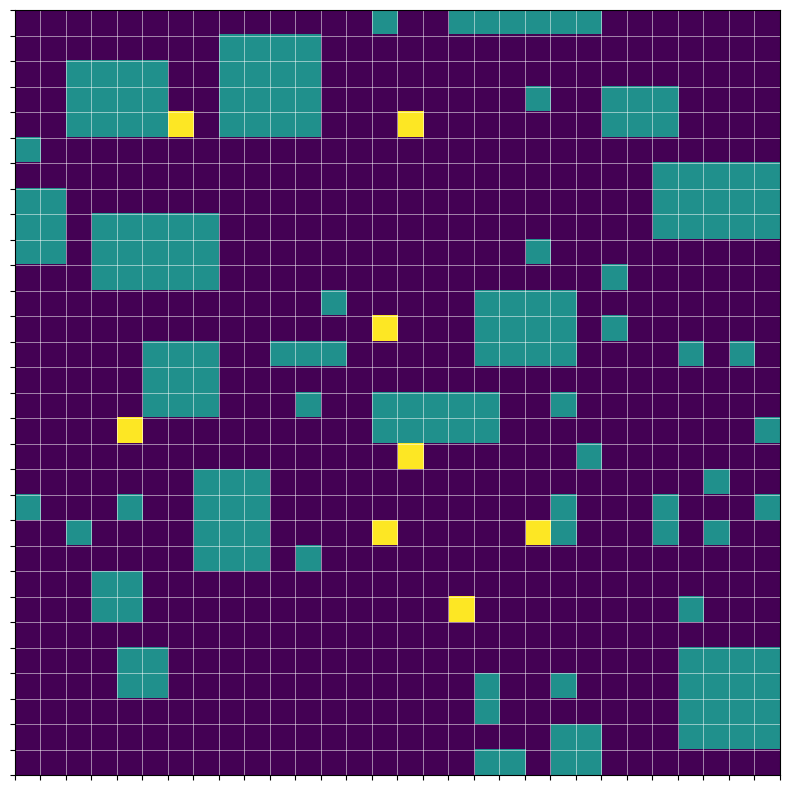

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Trực quan hóa đường đi Q-Learning
fig, ax = plt.subplots(figsize=(8, 8))

# Vẽ bản đồ (0=free, 1=obstacle)
# Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

# ======= THÊM LƯỚI Ô NGUYÊN  =======
n, m = grid.shape
ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
ax.set_aspect('equal')
ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')


plt.tight_layout()
# out_path_q = "/mnt/data/q_learning_path.png"
# plt.savefig(out_path_q, dpi=180)
plt.show() # Hiển thị biểu đồ đường đi Q-Learning
# plt.close(fig)
# print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

# Các hàm phụ trợ

In [53]:
# Kiểm tra điểm có nằm trong lưới không
def in_bounds(p, n, m):
    return 0 <= p[0] < n and 0 <= p[1] < m

# ---------- helpers ----------
MOVES8 = [(-1,-1), (-1,0), (-1,1),
          ( 0,-1),          ( 0,1),
          ( 1,-1), ( 1,0),  ( 1,1)]

# Hàm khoảng cách Euclid giữa hai điểm
def euclid(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

# Tính độ dài đường đi
def path_length(path):
    if not path or len(path) < 2:
        return 0.0
    return sum(euclid(path[i], path[i + 1]) for i in range(len(path) - 1))

In [54]:
# Tạo sub_grid từ start_point đến end_point
def create_sub_grid(start_point, end_point, grid):
    x_min = min(start_point[0], end_point[0])
    x_max = max(start_point[0], end_point[0])
    y_min = min(start_point[1], end_point[1])
    y_max = max(start_point[1], end_point[1])
    
    return grid[x_min:x_max+1, y_min:y_max+1]

In [55]:
# Tạo sub_grid từ start_point đến end_point bổ sung padding 1 ô xung quanh để tránh lỗi index khi đi chéo
def create_sub_grid_with_padding(start_point, end_point, grid, padding):
    x_min = min(start_point[0], end_point[0])
    x_max = max(start_point[0], end_point[0])
    y_min = min(start_point[1], end_point[1])
    y_max = max(start_point[1], end_point[1])
    
    return grid[x_min-padding:x_max+1+padding, y_min-padding:y_max+1+padding]

In [56]:
#test create_sub_grid
start_point = (4, 6)
end_point = (12, 14)
sub_grid = create_sub_grid(start_point, end_point, grid)
print("Sub-grid:")
print(sub_grid)

Sub-grid:
[[2 0 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 2]]


In [57]:
#test create_sub_grid_with_padding
start_point = (4, 6)
end_point = (12, 14)
padding = 1
sub_grid = create_sub_grid_with_padding(start_point, end_point, grid, padding)
print("Sub-grid với padding:")
print(sub_grid)

Sub-grid với padding:
[[1 0 0 1 1 1 1 0 0 0 0]
 [1 2 0 1 1 1 1 0 0 0 2]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 2 0]
 [1 1 1 0 0 1 1 1 0 0 0]]


# Các hàm tìm đường giữa 2 goal liên tiếp

In [58]:
# Tìm đường đi ngắn nhất từ start_point đến end_point chỉ đi xuống và sang phải (có thể đi chéo phải)
def find_path_segment_down_right(start_point, end_point, grid):
    sub_grid = create_sub_grid(start_point, end_point, grid)
    n, m = sub_grid.shape

    # B1: tính ma trận khoảng cách d
    d = np.full((n, m), fill_value=1e10, dtype=np.float64)
    d[0][0] = 0

    for i in range(1, n):
        if sub_grid[i][0] != 1:
            d[i][0] = min(d[i][0], d[i-1][0] + 1)

    for j in range(1, m):
        if sub_grid[0][j] != 1:
            d[0][j] = min(d[0][j], d[0][j-1] + 1)

    for i in range(1, n):
        for j in range(1, m):
            if sub_grid[i][j] != 1:
                d[i][j] = min(
                    d[i][j],
                    d[i-1][j] + 1,          # đi xuống
                    d[i][j-1] + 1,          # đi sang phải
                    d[i-1][j-1] + math.sqrt(2)  # đi chéo
                )

    print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][m-1])

    # B2: truy vết đường đi từ (n-1, m-1) về (0,0)
    path = []
    i, j = n-1, m-1

    if d[i, j] > 1e9:
        print("Không có đường đi hợp lệ tới đích")
        return [], 1e10
    else:
        while not (i == 0 and j == 0):
            path.append((i, j))
            found = False
            # Thử lần lượt: chéo, lên, trái (ưu tiên chéo cho đẹp)
            for di, dj, cost in [(-1, -1, math.sqrt(2)), (-1, 0, 1), (0, -1, 1)]:
                pi, pj = i + di, j + dj
                if pi < 0 or pj < 0:
                    continue
                # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
                if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                    i, j = pi, pj
                    found = True
                    break
            if not found:
                raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

        path.append((0, 0))
        path.reverse()
        # Cộng thêm offset để chuyển từ sub_grid về grid gốc
        offset_x = min(start_point[0], end_point[0])
        offset_y = min(start_point[1], end_point[1])
        path = [(x + offset_x, y + offset_y) for x, y in path]

        return path, d[n-1][m-1]

In [59]:
def find_path_segment_down_left(start_point, end_point, grid):
    sub_grid = create_sub_grid(start_point, end_point, grid)
    n, m = sub_grid.shape

    # B1: tính ma trận khoảng cách d
    d = np.full((n, m), fill_value=1e10, dtype=np.float64)
    d[0][m-1] = 0

    for i in range(1, n):
        if sub_grid[i][m-1] != 1:
            d[i][m-1] = min(d[i][m-1], d[i-1][m-1] + 1)

    for j in range(m-2, -1, -1):
        if sub_grid[0][j] != 1:
            d[0][j] = min(d[0][j], d[0][j+1] + 1)

    for i in range(1, n):
        for j in range(m-2, -1, -1):
            if sub_grid[i][j] != 1:
                d[i][j] = min(
                    d[i][j],
                    d[i-1][j] + 1,          # đi xuống
                    d[i][j+1] + 1,          # đi sang trái
                    d[i-1][j+1] + math.sqrt(2)  # đi chéo
                )

    print("Độ dài đường đi ngắn nhất tới đích:", d[n-1][0])

    # B2: truy vết đường đi từ (n-1, 0) về (0,m-1)
    path = []
    i, j = n-1, 0

    if d[i, j] > 1e9:
        print("Không có đường đi hợp lệ tới đích")
        return [], 1e10
    else:
        while not (i == 0 and j == m-1):
            path.append((i, j))
            found = False
            # Thử lần lượt: chéo, lên, phải (ưu tiên chéo cho đẹp)
            for di, dj, cost in [(-1, 1, math.sqrt(2)), (-1, 0, 1), (0, 1, 1)]:
                pi, pj = i + di, j + dj
                if pi < 0 or pj >= m:
                    continue
                # kiểm tra xem (pi,pj) có thể là cha của (i,j) không
                if abs(d[i, j] - (d[pi, pj] + cost)) < 1e-6:
                    i, j = pi, pj
                    found = True
                    break
            if not found:
                raise RuntimeError(f"Backtrack bị kẹt tại ô {(i, j)}")

        path.append((0, m-1))
        path.reverse()
        # Cộng thêm offset để chuyển từ sub_grid về grid gốc
        offset_x = min(start_point[0], end_point[0])
        offset_y = min(start_point[1], end_point[1])
        path = [(x + offset_x, y + offset_y) for x, y in path]
        return path, d[n-1][0]

In [60]:
import heapq

# Hàm tìm đường đi ngắn nhất giữa hai điểm (start_point) và (end_point) sử dụng Dijkstra
# Với khả năng di chuyển 8 hướng và tránh chướng ngại vật (giá trị 1)
# Độ phức tạp: O(n*m*log(n*m)) trong trường hợp xấu nhất, với n và m là số hàng và số cột của lưới
def dijkstra(grid_map, start_point, end_point):
    n_rows, n_cols = grid_map.shape

    # Kiểm tra điểm bắt đầu và kết thúc có hợp lệ không
    if not in_bounds(start_point, n_rows, n_cols) or grid_map[start_point[0]][start_point[1]] == 1:
        print(f"Điểm bắt đầu {start_point} không hợp lệ hoặc là chướng ngại vật.")
        return [], 1e10 # Trả về đường đi rỗng và độ dài vô cùng lớn nếu điểm bắt đầu không hợp lệ
    if not in_bounds(end_point, n_rows, n_cols) or grid_map[end_point[0]][end_point[1]] == 1:
        print(f"Điểm kết thúc {end_point} không hợp lệ hoặc là chướng ngại vật.")
        return [], 1e10

    # distances lưu trữ khoảng cách ngắn nhất từ start_point đến mỗi ô
    # dictionary (row, col) -> min distance giữa start_point và (row, col), kích thước n_rows x n_cols
    distances = { (r, c): 1e10 for r in range(n_rows) for c in range(n_cols) } 
    distances[start_point] = 0

    # predecessors lưu trữ ô trước đó trong đường đi ngắn nhất, dạng dictionary (row, col) -> (prev_row, prev_col)
    predecessors = {}

    # priority_queue (min-heap) để lưu trữ (khoảng_cách, ô_hiện_tại), trong đó khoảng cách là khoảng cách ngắn nhất đã biết từ start_point đến ô_hiện_tại
    priority_queue = [ (0, start_point) ]

    while priority_queue: # Trong khi hàng đợi ưu tiên không rỗng
        current_distance, current_node = heapq.heappop(priority_queue) # Lấy ô có khoảng cách nhỏ nhất từ hàng đợi
        # print(f"Đang xử lý node {current_node} với khoảng cách {current_distance}")
        # print(f"Hàng đợi ưu tiên: {priority_queue}")

        # Nếu đã tìm thấy đường đi ngắn nhất đến current_node rồi, bỏ qua
        if current_distance > distances[current_node]:
            continue

        # Nếu đã đến đích, dừng tìm kiếm
        if current_node == end_point:
            break

        # Duyệt qua 8 ô lân cận
        for dr, dc in MOVES8:
            neighbor_node = (current_node[0] + dr, current_node[1] + dc)

            # Kiểm tra ô lân cận có hợp lệ không (trong biên, không phải chướng ngại vật)
            if in_bounds(neighbor_node, n_rows, n_cols) and grid_map[neighbor_node[0]][neighbor_node[1]] != 1:
                # Tính chi phí di chuyển (1 cho ngang/dọc, sqrt(2) cho chéo)
                move_cost = math.hypot(dr, dc) # math.hypot((dr, dc)) will be 1 or sqrt(2)

                # Tính khoảng cách mới đến ô lân cận
                new_distance = current_distance + move_cost

                # Nếu tìm thấy đường đi ngắn hơn đến ô lân cận
                if new_distance < distances[neighbor_node]:
                    distances[neighbor_node] = new_distance
                    # print(distances)
                    predecessors[neighbor_node] = current_node
                    # print(predecessors)
                    heapq.heappush(priority_queue, (new_distance, neighbor_node))

    # Tái tạo đường đi từ end_point về start_point
    path = []
    if distances[end_point] == 1e10: # Không tìm thấy đường đi
        return [], 1e10

    current = end_point
    while current != start_point:
        path.append(current)
        current = predecessors.get(current)
        if current is None: # Lỗi: không thể truy vết về điểm bắt đầu
            return [], 1e10
    path.append(start_point)
    path.reverse()

    return path, distances[end_point]

In [61]:
# test dijkstra
gridtest = np.array([[0, 0, 1, 0, 0],
                     [0, 1, 1, 1, 0],
                     [0, 1, 0, 1, 0],
                     [1, 1, 0, 0, 0],
                     [0, 0, 1, 1, 0]])
path, dist = dijkstra(gridtest, (0, 0), (0, 4))
print("Đường đi ngắn nhất từ (0,0) đến (0,4):", path)
print("Độ dài đường đi:", dist)

Đường đi ngắn nhất từ (0,0) đến (0,4): []
Độ dài đường đi: 10000000000.0


In [62]:
def find_path_segment_with_dijkstra(start_point, end_point, grid, padding):
    sub_grid = create_sub_grid_with_padding(start_point, end_point, grid, padding)
    # down, right
    if start_point[0] <= end_point[0] and start_point[1] <= end_point[1]:
        path, dist = dijkstra(sub_grid, (padding, padding), (sub_grid.shape[0]-1-padding, sub_grid.shape[1]-1-padding))
    elif start_point[0] <= end_point[0] and start_point[1] > end_point[1]: # down, left
        path, dist = dijkstra(sub_grid, (padding, sub_grid.shape[1]-1-padding), (sub_grid.shape[0]-1-padding, padding))
    elif start_point[0] > end_point[0] and start_point[1] <= end_point[1]: # up, right
        path, dist = dijkstra(sub_grid, (sub_grid.shape[0]-1-padding, padding), (padding, sub_grid.shape[1]-1-padding))
    else: # up, left
        path, dist = dijkstra(sub_grid, (sub_grid.shape[0]-1-padding, sub_grid.shape[1]-1-padding), (padding, padding))
    
    # Cộng thêm offset để chuyển từ sub_grid về grid gốc
    offset_x = min(start_point[0], end_point[0]) - padding
    offset_y = min(start_point[1], end_point[1]) - padding
    path = [(x + offset_x, y + offset_y) for x, y in path]
    
    return path, dist

In [63]:
# test find_path_segment_with_dijkstra
start_point = (4, 6)
end_point = (4, 15)
padding = 1
path, dist = find_path_segment_with_dijkstra(start_point, end_point, grid, padding)
print("Đường đi tìm được bởi Dijkstra:")
print(path)
print("Độ dài đường đi:", dist)

Đường đi tìm được bởi Dijkstra:
[(4, 6), (4, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (4, 14), (4, 15)]
Độ dài đường đi: 9.82842712474619


In [64]:
# Hàm chính để tìm đường đi ngắn nhất qua các điểm bắt buộc
def find_shortest_path_with_mandatory_waypoints(grid_map, start_node, end_node, mandatory_waypoints):
    # Sắp xếp các điểm bắt buộc để đảm bảo di chuyển xuống và sang phải
    # Nếu không sắp xếp, có thể có trường hợp không tìm được đường đi với ràng buộc này
    sorted_waypoints = sorted(mandatory_waypoints)

    # Tạo danh sách tất cả các điểm cần đi qua theo thứ tự: Start -> Waypoints (sắp xếp) -> End
    all_points = [start_node] + sorted_waypoints + [end_node]

    total_path = []
    total_length = 0.0

    # Duyệt qua từng đoạn đường giữa các điểm liên tiếp
    for i in range(len(all_points) - 1):
        segment_start = all_points[i]
        segment_end = all_points[i+1]

        print(f"Đang tìm đường đi từ {segment_start} đến {segment_end}...")
        if segment_start[0] <= segment_end[0] and segment_start[1] <= segment_end[1]:
            # Di chuyển xuống và sang phải
            current_segment_path, current_segment_length = find_path_segment_down_right(segment_start, segment_end, grid_map)
        elif segment_start[0] <= segment_end[0] and segment_start[1] >= segment_end[1]:
            # Di chuyển xuống và sang trái
            current_segment_path, current_segment_length = find_path_segment_down_left(segment_start, segment_end, grid_map)

        pad =  1
        while current_segment_length > 1e9: # Nếu không tìm thấy đường đi cho một đoạn
            current_segment_path, current_segment_length = find_path_segment_with_dijkstra(segment_start, segment_end, grid_map, padding=pad)
            print(f"Đã thử với padding={pad}, độ dài đường đi: {current_segment_length}")
            pad += 1

        # Nối đoạn đường hiện tại vào tổng đường đi
        # Tránh lặp lại điểm cuối của đoạn trước (điểm bắt đầu của đoạn hiện tại)
        if i > 0:
            total_path.extend(current_segment_path[1:])
        else:
            total_path.extend(current_segment_path)

        total_length += current_segment_length

    return total_path, total_length

In [65]:
# --- Thực thi chính ---
start_exec_time = time.time()

start_node = (0, 0)
end_node = (n-1, n-1)

# Trích xuất các điểm bắt buộc (giá trị 2) từ bản đồ
mandatory_waypoints = []
for r in range(n):
    for c in range(n):
        if grid[r][c] == 2:
            mandatory_waypoints.append((r, c))

print(f"Các điểm bắt buộc phải đi qua được tìm thấy: {mandatory_waypoints}")
if not mandatory_waypoints:
    print("Không có điểm bắt buộc nào (số 2) trên bản đồ. Giải thuật sẽ tìm đường đi từ (0,0) đến (n-1,n-1) bình thường.")
    # Fallback to original single-segment path if no waypoints
    path, L_q = find_path_segment_with_dijkstra(start_node, end_node, grid)
else:
    path, L_q = find_shortest_path_with_mandatory_waypoints(grid, start_node, end_node, mandatory_waypoints)

end_exec_time = time.time()

if L_q > 1e9:
    print("Không tìm thấy đường đi hợp lệ bao gồm tất cả các điểm bắt buộc.")
else:
    print(f"\nĐộ dài đường đi ngắn nhất qua tất cả các điểm bắt buộc: {L_q:.2f}")
    print("Đường đi (theo thứ tự):")
    # For very long paths, printing all might be excessive, but for 30x30, it's ok.
    for cell in path:
        print(cell)

print(f"Thời gian chạy: {end_exec_time - start_exec_time:.6f} giây")

Các điểm bắt buộc phải đi qua được tìm thấy: [(4, 6), (4, 15), (12, 14), (16, 4), (17, 15), (20, 14), (20, 20), (23, 17)]
Đang tìm đường đi từ (0, 0) đến (4, 6)...
Độ dài đường đi ngắn nhất tới đích: 8.82842712474619
Đang tìm đường đi từ (4, 6) đến (4, 15)...
Độ dài đường đi ngắn nhất tới đích: 10000000000.0
Không có đường đi hợp lệ tới đích
Đã thử với padding=1, độ dài đường đi: 9.82842712474619
Đang tìm đường đi từ (4, 15) đến (12, 14)...
Độ dài đường đi ngắn nhất tới đích: 8.414213562373096
Đang tìm đường đi từ (12, 14) đến (16, 4)...
Độ dài đường đi ngắn nhất tới đích: 11.65685424949238
Đang tìm đường đi từ (16, 4) đến (17, 15)...
Độ dài đường đi ngắn nhất tới đích: 11.414213562373096
Đang tìm đường đi từ (17, 15) đến (20, 14)...
Độ dài đường đi ngắn nhất tới đích: 3.414213562373095
Đang tìm đường đi từ (20, 14) đến (20, 20)...
Độ dài đường đi ngắn nhất tới đích: 6.0
Đang tìm đường đi từ (20, 20) đến (23, 17)...
Độ dài đường đi ngắn nhất tới đích: 4.242640687119286
Đang tìm đường đ


Đường đi được trích xuất:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 5), (2, 6), (3, 6), (4, 6), (4, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (4, 14), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15), (9, 15), (10, 15), (11, 15), (12, 14), (13, 13), (14, 12), (14, 11), (14, 10), (14, 9), (15, 8), (16, 7), (16, 6), (16, 5), (16, 4), (16, 5), (16, 6), (16, 7), (16, 8), (16, 9), (16, 10), (16, 11), (16, 12), (16, 13), (17, 14), (17, 15), (18, 15), (19, 15), (20, 14), (20, 15), (20, 16), (20, 17), (20, 18), (20, 19), (20, 20), (21, 19), (22, 18), (23, 17), (23, 18), (23, 19), (23, 20), (24, 21), (25, 22), (26, 23), (27, 24), (28, 25), (29, 26), (29, 27), (29, 28), (29, 29)]
Độ dài đường đi: 78.284

Đang trực quan hóa đường đi Q-Learning...


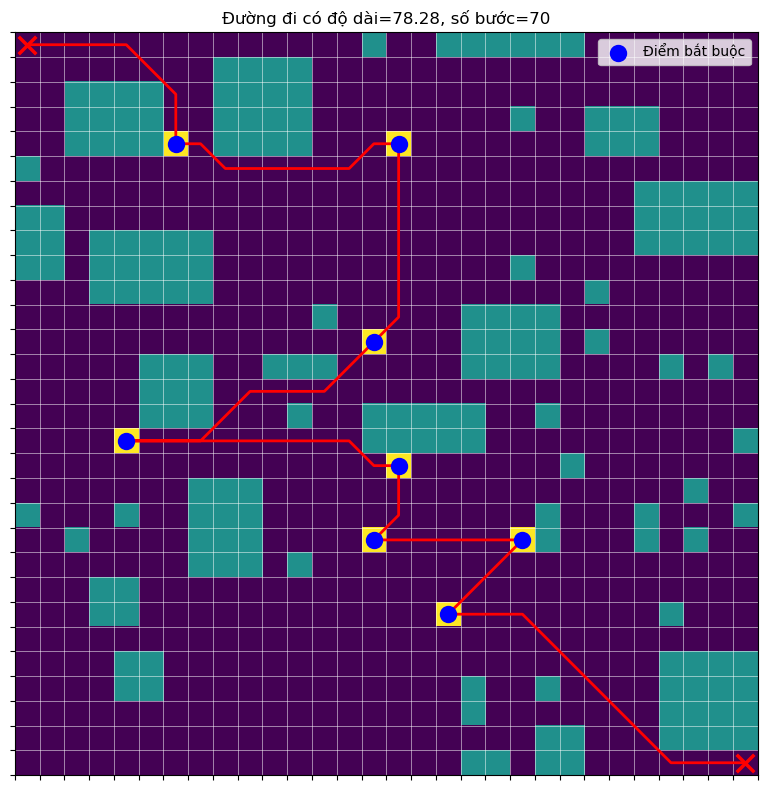

In [66]:
visualize_path(grid, path, mandatory_waypoints)